In [ ]:
import pandas as pd
df=pd.read_csv("DataCoSupplyChainDataset.csv",encoding='ISO-8859-1')

In [ ]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [ ]:
# Display the first few rows to verify the data load
print("=== First 5 Rows of Supply Chain Dataset ===")
print(df.head())

=== First 5 Rows of Supply Chain Dataset ===
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0           73  Sporting Goods        Caguas  ...   
1  

In [ ]:
print("\n=== Missing Values Count ===")
missing_values = df.isnull().sum()
print(missing_values)


=== Missing Values Count ===
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market    

In [ ]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')

features_with_missing_values(df)

Percentage of Total Missing Values is  3.51 %
Missing Value Estimation :
The Feature  Customer Lname  has 8 missing values
The Feature  Customer Zipcode  has 3 missing values
The Feature  Order Zipcode  has 155679 missing values
The Feature  Product Description  has 180519 missing values


In [ ]:
print(f"Dataset rows: {df.shape[0]}")
print(f"Dataset columns: {df.shape[1]}")

Dataset rows: 180519
Dataset columns: 53


In [ ]:
modeling_columns = ['Type',
                  'Days for shipping (real)',
                  'Days for shipment (scheduled)',
                  'Benefit per order',
                  'Sales per customer',
                  'Latitude',
                  'Longitude',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Total',
                  'Order Profit Per Order',
                  'Order Status',
                  'Shipping Mode',
                  'Late_delivery_risk']

In [ ]:
len(modeling_columns)

14

In [ ]:
def drop_columns(dataset, columns_to_drop):
    dataset = dataset.drop(columns=columns_to_drop)
    print(f"{len(columns_to_drop)} columns dropped successfully. Number of columns remaining: {len(dataset.columns)}")
    return dataset

In [ ]:
columns_to_drop = [col for col in df.columns if col not in modeling_columns]

In [ ]:
len(columns_to_drop)

39

In [ ]:
df1=drop_columns(df,columns_to_drop)

39 columns dropped successfully. Number of columns remaining: 14


In [ ]:
print(f"Dataset rows: {df1.shape[0]}")
print(f"Dataset columns: {df1.shape[1]}")

Dataset rows: 180519
Dataset columns: 14


In [ ]:
set(df1['Late_delivery_risk'])

{0, 1}

In [ ]:
df1['Late_delivery_risk'].value_counts()


Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [ ]:
df1.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Total',
       'Order Profit Per Order', 'Order Status', 'Shipping Mode'],
      dtype='object')

In [ ]:
# check null values
df1.isna().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Late_delivery_risk               0
Latitude                         0
Longitude                        0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Total                 0
Order Profit Per Order           0
Order Status                     0
Shipping Mode                    0
dtype: int64

In [ ]:
#analyze categorical columns
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
   unique_values = df1[col].unique()
   num_unique = len(unique_values)
   print(f"\nColumn: {col}")
   print(f"Number of unique values: {num_unique}")
   #print("Unique values:")
   #print(unique_values)


Column: Type
Number of unique values: 4

Column: Order Status
Number of unique values: 9

Column: Shipping Mode
Number of unique values: 4


In [ ]:
df1.duplicated().sum()

4

In [ ]:
df1[df1.duplicated()]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
94789,DEBIT,5,4,53.230000,118.290001,1,28.102118,-82.512115,11.7,0.09,118.290001,53.230000,COMPLETE,Standard Class
137818,PAYMENT,2,4,138.589996,395.980011,0,21.287289,-157.671402,4.0,0.01,395.980011,138.589996,PENDING_PAYMENT,Standard Class
146875,DEBIT,2,2,93.599998,359.980011,0,29.780575,-95.171997,40.0,0.10,359.980011,93.599998,COMPLETE,Second Class
175279,DEBIT,2,1,120.949997,335.980011,1,18.380119,-66.183128,64.0,0.16,335.980011,120.949997,COMPLETE,First Class


In [ ]:
df1=df1.drop_duplicates()

In [ ]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,COMPLETE,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,PENDING,Standard Class
2,CASH,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,CLOSED,Standard Class
3,DEBIT,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,COMPLETE,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,PENDING_PAYMENT,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,CLOSED,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,COMPLETE,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,PENDING,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,PENDING_PAYMENT,Standard Class


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Type','Order Status', 'Shipping Mode']
le = LabelEncoder()
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col])

In [ ]:
df1

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,0,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,1,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,0,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,0,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,0,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,0,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,1,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,1,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,0,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [ ]:
X = df1.drop(columns=['Late_delivery_risk'])  # features
y = df1['Late_delivery_risk']                 # target

In [ ]:
X

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Total,Order Profit Per Order,Order Status,Shipping Mode
0,1,3,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,314.640015,91.250000,2,3
1,3,5,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,311.359985,-249.089996,5,3
2,0,4,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,309.720001,-247.779999,1,3
3,1,3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,304.809998,22.860001,2,3
4,2,2,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,298.250000,134.210007,6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,0,4,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,40.000000,1,3
180515,1,3,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,395.980011,-613.770019,2,2
180516,3,5,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,391.980011,141.110001,5,3
180517,2,3,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,387.980011,186.229996,6,3


In [ ]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 180515, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_remaining ,y_train ,y_remaining=train_test_split(X,y,test_size=0.4,random_state=42)

#spliting the remaining data into testing and validation

X_val,X_test,y_val,y_test=train_test_split(X_remaining ,y_remaining , test_size=0.5,random_state=42)

In [ ]:
X_train.shape, X_val.shape ,X_test.shape , y_train.shape, y_val.shape ,y_test.shape

((108309, 13), (36103, 13), (36103, 13), (108309,), (36103,), (36103,))

In [ ]:
#mlp

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(hidden_layer_sizes=(50,50),max_iter=1000,random_state=42)

In [ ]:
mlp.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=42)

In [ ]:
y_pred=mlp.predict(X_test)
print("testing Accuracy:", accuracy_score(y_test,y_pred))

testing Accuracy: 0.9982826911890978


In [ ]:
y_pred_train=mlp.predict(X_train)
print("training Accuracy:", accuracy_score(y_train,y_pred_train))

training Accuracy: 0.9983565539336527


In [ ]:
y_pred_val=mlp.predict(X_val)
print("validation Accuracy:", accuracy_score(y_val,y_pred_val))

validation Accuracy: 0.9984211838351383


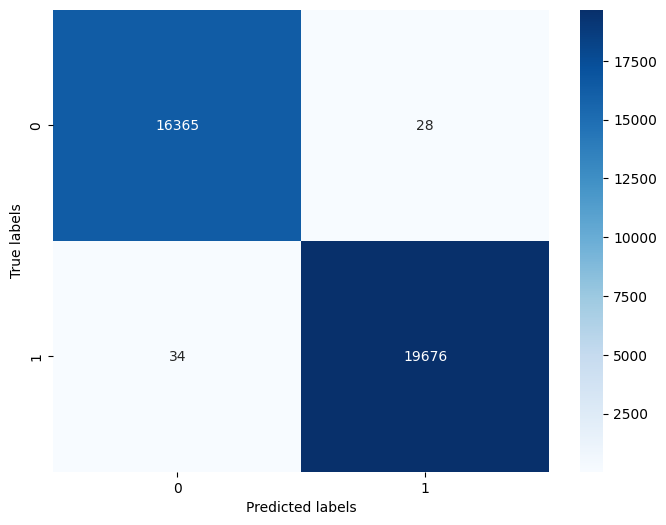

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,y_pred),fmt='d',annot=True, cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.show()

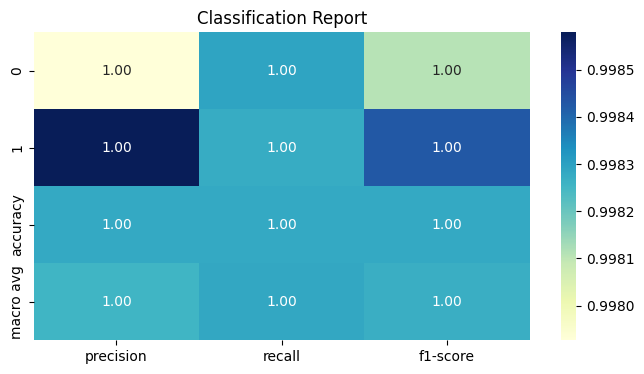

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 4))
sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.show()

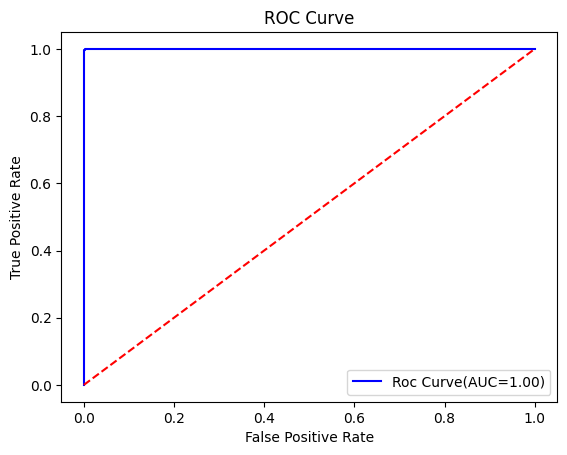

AUC Score: 0.9999701305481672


In [ ]:
from sklearn.metrics import roc_curve,auc,roc_auc_score
import matplotlib.pyplot as precision_recall_fscore_support

y_pred_proba=mlp.predict_proba(X_test)[:,1]

fpr,tpr,threshold=roc_curve(y_test,y_pred_proba)

auc_value=auc(fpr,tpr)

plt.plot(fpr,tpr,color='blue',label=f'Roc Curve(AUC={auc_value:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("AUC Score:",roc_auc_score(y_test,y_pred_proba))

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,matthews_corrcoef,cohen_kappa_score,precision_score,recall_score,f1_score
cm=confusion_matrix(y_test,y_pred)
report=classification_report(y_test,y_pred)
mcc=matthews_corrcoef(y_test,y_pred)
kappa=cohen_kappa_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)

In [ ]:
tn,fp,fn,tp=cm.ravel()

In [ ]:
tn,fp,fn,tp

(16365, 28, 34, 19676)

In [ ]:
fpr=fp/(fp+tn)
fnr=fn/(fn+tp)

In [ ]:
mcc,kappa,precision,recall,f1,fpr,fnr

(0.9965363059210658,
 0.996536249935592,
 0.9985789687373122,
 0.9982749873160832,
 0.9984269548891257,
 0.0017080461172451656,
 0.0017250126839167936)